In [36]:
import pandas as pd


In [49]:
data = {
    ('Orange',17): [5,4,2.9,2,1,1,1.9,2.9,4,5],
    ('Orange',28.8): [8.6,6.8,5,3.4,1.7,1.7,3.4,5.1,6.9,8.6],
    ('Orange',71.3): [21.4,16.8,12.5,8.3,4.1,4.1,8.3,12.5,16.7,21.4],

    ('Grün',17):   [4.7,3.7,2.7,1.8,0.8,0.9,1.8,2.7,3.7,4.7],
    ('Grün',27.3):   [8.1,6.4,4.7,3.1,1.5,1.5,3.2,4.7,6.4,8.0],
    ('Grün',71.3):   [20.2,15.9,11.8,7.8,3.9,3.9,7.8,11.8,15.8,20.2],

    ('Blau',17):   [3.5,2.8,2.2,1.3,0.7,0.7,1.5,2.3,2.9,3.5],
    ('Blau',28.8):   [6.2,4.9,3.7,2.6,1.3,1.2,2.4,3.7,4.9,6.2],
    ('Blau',71.3):   [15.9,12.6,9.4,6.3,3.1,3.1,6.3,9.4,12.6,15.9],
}

In [50]:
df = pd.DataFrame(data)

In [51]:
df

Orange            Grün            Blau           
    17.0 28.8  71.3 17.0 27.3  71.3 17.0 28.8  71.3
0    5.0  8.6  21.4  4.7  8.1  20.2  3.5  6.2  15.9
1    4.0  6.8  16.8  3.7  6.4  15.9  2.8  4.9  12.6
2    2.9  5.0  12.5  2.7  4.7  11.8  2.2  3.7   9.4
3    2.0  3.4   8.3  1.8  3.1   7.8  1.3  2.6   6.3
4    1.0  1.7   4.1  0.8  1.5   3.9  0.7  1.3   3.1
5    1.0  1.7   4.1  0.9  1.5   3.9  0.7  1.2   3.1
6    1.9  3.4   8.3  1.8  3.2   7.8  1.5  2.4   6.3
7    2.9  5.1  12.5  2.7  4.7  11.8  2.3  3.7   9.4
8    4.0  6.9  16.7  3.7  6.4  15.8  2.9  4.9  12.6
9    5.0  8.6  21.4  4.7  8.0  20.2  3.5  6.2  15.9

Blau chi2_red = 5.573254743874149
Plot gespeichert als: beugungsgitter_blau.svg


/var/folders/8y/gymqg4894ts6f9xy8bg2j3g00000gn/T/ipykernel_76891/283888939.py:63: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_wide


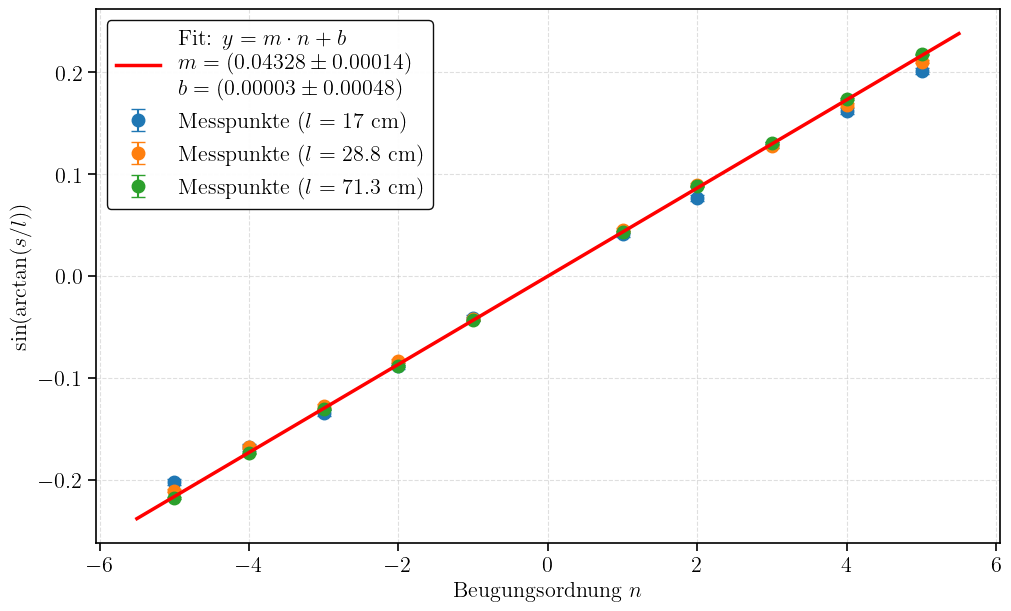

Grün chi2_red = 7.17803672365296
Plot gespeichert als: beugungsgitter_grün.svg


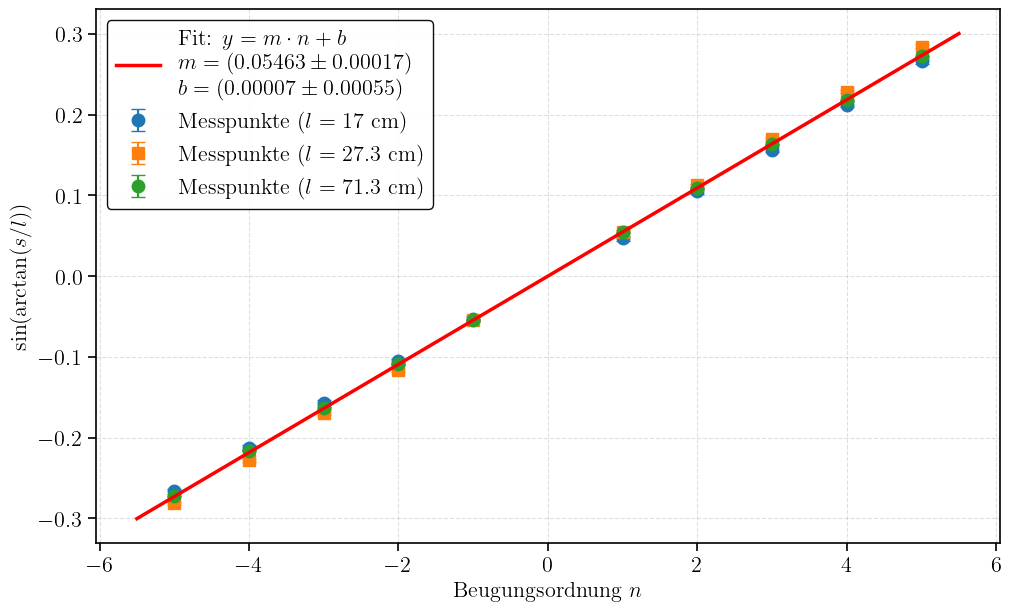

Orange chi2_red = 1.1470114888809928
Plot gespeichert als: beugungsgitter_orange.svg


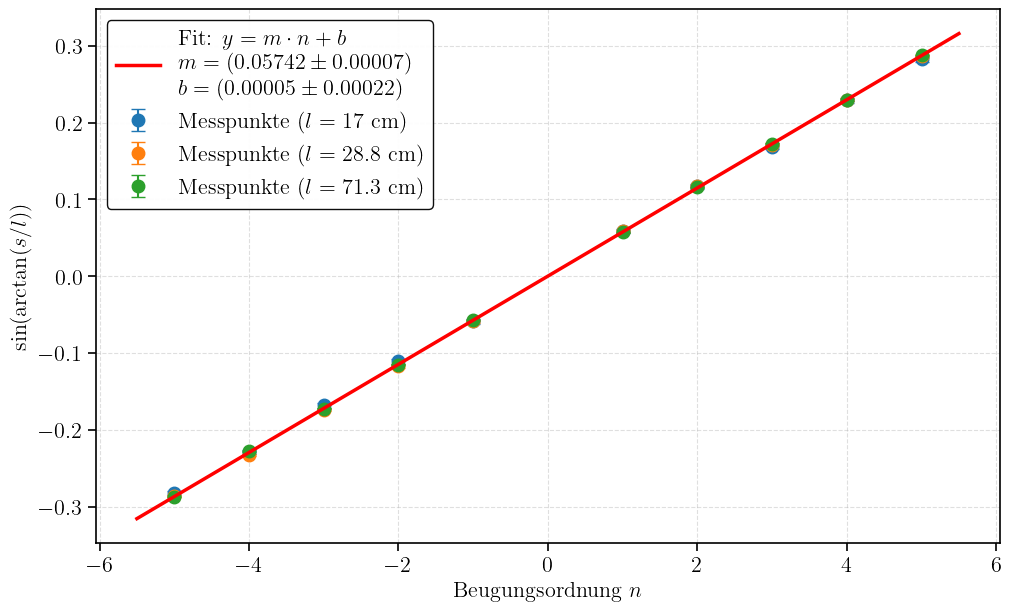


ERGEBNISSE DER BEUGUNGSGITTER-AUSWERTUNG

BLAU
  m  = 0.04328+/-0.00014
  b  = 0.0000+/-0.0005
  λ  = 432.8+/-1.7 nm

GRÜN
  m  = 0.05463+/-0.00017
  b  = 0.0001+/-0.0005
  λ  = 546.3+/-2.0 nm

ORANGE
  m  = 0.05742+/-0.00007
  b  = 0.00005+/-0.00022
  λ  = 574.2+/-1.3 nm


In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from uncertainties import ufloat
from uncertainties import unumpy as unp

# Matplotlib-Einstellungen für beste Qualität mit LaTeX-Style Schriften

# Font- und Render-Einstellungen (LaTeX-Style)

plt.rcParams["text.usetex"] = True
plt.rcParams['font.size'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 17
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16

# Linien und Marker
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8
plt.rcParams['errorbar.capsize'] = 5

# DPI und Qualität
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['figure.constrained_layout.use'] = True

# Achsen-Styling
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

# -----------------------------
# 0) Annahmen / Unsicherheiten
# -----------------------------
sigma_s_cm = 0.05   # ±0.5 mm = 0.05 cm
sigma_l_cm = 0.10   # ±1 mm   = 0.10 cm

a_um = 10.00
sigma_a_um = a_um * 0.002     # ±0.2%
a_u = ufloat(a_um, sigma_a_um)  # µm

orders = np.array([5,4,3,2,1,-1,-2,-3,-4,-5], dtype=int)

# -----------------------------
# 1) Wide(MultiIndex) -> Long
# -----------------------------
# df: index 0..9, columns MultiIndex (color, l)
df_wide = df.copy()

# Ordnung als Index setzen
df_wide = df_wide.copy()
df_wide["n"] = orders
df_wide = df_wide.set_index("n")

# Long-Format erzeugen: Spalten -> Zeilen
# Ergebnis: index=(n), columns=(color,l) -> (n,color,l,s)
df_long = (
    df_wide
    .stack(level=[0,1], dropna=False)   # MultiIndex columns -> MultiIndex rows
    .rename("s")
    .reset_index()
)
df_long.columns = ["n", "color", "l", "s"]


# -----------------------------
# 2) y = sin(arctan(s/l)) als uarray
# -----------------------------
# signed s (links negativ)
s_signed = df_long["s"].to_numpy(dtype=float) * np.sign(df_long["n"].to_numpy(dtype=int))

# ufloat arrays (NaNs bleiben NaNs in nominal arrays; wir filtern später)
s_u = unp.uarray(s_signed, sigma_s_cm)
l_u = unp.uarray(df_long["l"].to_numpy(dtype=float), sigma_l_cm)

y_u = s_u / unp.sqrt(s_u**2 + l_u**2)

df_long["y_nom"] = unp.nominal_values(y_u)
df_long["y_std"] = unp.std_devs(y_u)

# -----------------------------
# 3) Weighted linear regression y = m*n + b
# -----------------------------

def weighted_fit(n, y, sigma_y, scale_with_chi2=True):
    n = np.asarray(n, float)
    y = np.asarray(y, float)
    sigma_y = np.asarray(sigma_y, float)

    mask = np.isfinite(n) & np.isfinite(y) & np.isfinite(sigma_y) & (sigma_y > 0)
    n, y, sigma_y = n[mask], y[mask], sigma_y[mask]

    w = 1.0 / sigma_y**2

    S   = np.sum(w)
    Sx  = np.sum(w * n)
    Sy  = np.sum(w * y)
    Sxx = np.sum(w * n * n)
    Sxy = np.sum(w * n * y)

    Delta = S * Sxx - Sx**2

    m = (S * Sxy - Sx * Sy) / Delta
    b = (Sxx * Sy - Sx * Sxy) / Delta

    # Standardfehler (für bekannte sigma_y)
    var_m = S / Delta
    var_b = Sxx / Delta

    # Chi^2 red zur Skalierung (optional)
    if scale_with_chi2:
        yhat = m*n + b
        chi2 = np.sum(((y - yhat) / sigma_y)**2)
        dof = len(n) - 2
        chi2_red = chi2 / dof if dof > 0 else 1.0
        scale = np.sqrt(chi2_red) if chi2_red > 1 else 1.0
        var_m *= scale**2
        var_b *= scale**2
    else:
        chi2_red = np.nan

    return ufloat(m, np.sqrt(var_m)), ufloat(b, np.sqrt(var_b)), chi2_red

# -----------------------------
# 4) Pro Farbe fitten + λ berechnen + Plot
# -----------------------------
results = []

marker_map = {15.5: "o", 27.3: "s", 69.8: "^"}   # unterschiedliche Marker pro Abstand

for color in sorted(df_long["color"].unique()):
    sub = df_long[(df_long["color"] == color) & df_long["s"].notna()].copy()

    n  = sub["n"].to_numpy(dtype=int)
    y  = sub["y_nom"].to_numpy(dtype=float)
    sy = sub["y_std"].to_numpy(dtype=float)
    lvals = sub["l"].to_numpy(dtype=float)

    m_u, b_u, chi2_red = weighted_fit(n, y, sy, scale_with_chi2=True)
    print(color, "chi2_red =", chi2_red)

    lam_u_um = a_u * m_u
    lam_u_nm = lam_u_um * 1000.0  # nm

    results.append({"Farbe": color, "m": m_u, "b": b_u, "lambda_nm": lam_u_nm})

    # Fit-Linie
    xs = np.linspace(n.min() - 0.5, n.max() + 0.5, 300)
    m_nom = unp.nominal_values(m_u)
    b_nom = unp.nominal_values(b_u)
    y_fit = m_nom * xs + b_nom

    fig, ax = plt.subplots(figsize=(10, 6), dpi=100, constrained_layout=True)

    # --- Messpunkte mit Fehlerbalken, getrennt nach l (für saubere Legende) ---
    for l in sorted(np.unique(lvals)):
        mask_l = (lvals == l)
        ax.errorbar(
            n[mask_l], y[mask_l], yerr=sy[mask_l],
            fmt=marker_map.get(float(l), "o"),
            capsize=5,
            linestyle="none",
            label=f"Messpunkte ($l = {l:g}$ cm)",
            markersize=9,
            linewidth=1.5,
            elinewidth=1.5
        )

    # --- Fit-Gerade mit Legenden-Eintrag ---
    ax.plot(
        xs, y_fit,
        label=(f"Fit: $y = m \\cdot n + b$\n" +
               f"$m = ({m_u.nominal_value:.5f} \\pm {m_u.std_dev:.5f})$\n" +
               f"$b = ({b_u.nominal_value:.5f} \\pm {b_u.std_dev:.5f})$"),
        linewidth=2.5, color='red', zorder=5
    )

    ax.set_xlabel(r"Beugungsordnung $n$")
    ax.set_ylabel(r"$\sin(\arctan(s/l))$")
    ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
    ax.legend(loc="best", frameon=True, framealpha=0.95, edgecolor='black', fancybox=True)

    # SVG speichern
    filename = f"beugungsgitter_{color.lower()}.svg"
    plt.savefig(filename, format='svg', bbox_inches='tight', dpi=150)
    print(f"Plot gespeichert als: {filename}")

    plt.show()

# Ausgabe (optional)
print("\n" + "="*60)
print("ERGEBNISSE DER BEUGUNGSGITTER-AUSWERTUNG")
print("="*60)
for r in results:
    print(f"\n{r['Farbe'].upper()}")
    print(f"  m  = {r['m']}")
    print(f"  b  = {r['b']}")
    print(f"  λ  = {r['lambda_nm']} nm")

In [35]:
import numpy as np
import pandas as pd

a_um = 10.0
df_check = df_long[df_long["s"].notna()].copy()

# sin(alpha) mit Vorzeichen
s_signed = df_check["s"].to_numpy(float) * np.sign(df_check["n"].to_numpy(int))
l = df_check["l"].to_numpy(float)
sin_alpha = s_signed / np.sqrt(df_check["s"].to_numpy(float)**2 + l**2)

# lambda pro Punkt (in nm)
df_check["lambda_nm_point"] = (a_um * 1000) * (sin_alpha / df_check["n"].to_numpy(int))  # 10um=10000nm, aber hier a_um*1000 = 10000
# genauer: a_um * 1000 = 10000 nm, passt.

# nur blau anzeigen
df_check[df_check["color"]=="Blau"][["n","l","s","lambda_nm_point"]]

,n,l,s,lambda_nm_point
9,4,15.5,2.8,444.419811
18,3,15.5,2.2,468.423452
19,3,27.3,5.1,612.120967
27,2,15.5,1.3,417.887633
28,2,27.3,2.6,474.045463
29,2,69.8,6.3,449.462343
36,1,15.5,0.7,451.153065
37,1,27.3,1.3,475.651494
38,1,69.8,3.1,443.688707
45,-1,15.5,0.7,451.153065


In [64]:
import numpy as np
from uncertainties import ufloat
from uncertainties import unumpy as unp

# Messwert (Beispiel: Orange, n=5)
s_cm = ufloat(21.4, 0.05)   # s = 8.6 cm ± 0.05 cm (0.5 mm)
l_cm = ufloat(71.3, 0.10)  # l = 17.0 cm ± 0.10 cm (1 mm)

# "exakt" für eure Auswertung:
sin_exact = s_cm / unp.sqrt(s_cm**2 + l_cm**2)   # = sin(arctan(s/l))

# Kleinwinkelnäherung, die oft (fälschlich) verwendet wird:
sin_small = s_cm / l_cm                          # = tan(alpha) = s/l  (≈ sin alpha)

# Abweichungen
delta_abs = sin_small - sin_exact
delta_rel = delta_abs / sin_exact                # relative Abweichung

# Ausgabe mit LaTeX-Formatierung
print("\n" + "="*70)
print("VERGLEICH: EXAKTE BERECHNUNG vs. KLEINWINKELNÄHERUNG")
print("="*70)
print(f"\nEingabedaten:")
print(f"  s = {s_cm} cm")
print(f"  l = {l_cm} cm")
print(f"\nErgebnisse:")
print(f"  sin(arctan(s/l)) = {sin_exact}")
print(f"  s/l (Näherung)   = {sin_small}")
print(f"\nAbweichung:")
print(f"  Absolut: Δ = {delta_abs}")
print(f"  Relativ: Δ_rel = {delta_rel}")
print(f"  In Prozent: {100*delta_rel:.2%}")


VERGLEICH: EXAKTE BERECHNUNG vs. KLEINWINKELNÄHERUNG

Eingabedaten:
  s = 21.40+/-0.05 cm
  l = 71.30+/-0.10 cm

Ergebnisse:
  sin(arctan(s/l)) = 0.2875+/-0.0007
  s/l (Näherung)   = 0.3001+/-0.0008

Abweichung:
  Absolut: Δ = 0.01267+/-0.00010
  Relativ: Δ_rel = 0.04407+/-0.00024
  In Prozent: (440.71+/-2.35)%
